In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.utils.class_weight import compute_class_weight
import joblib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

DATA_DIR  = Path('../data')
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Computing device: {device}')


PyTorch version : 2.5.1+cu121
Computing device: cuda


In [31]:
plus_files = sorted(DATA_DIR.glob('*_plus.csv'))
print(f'Znalezione pliki: {len(plus_files)}')

def load_file(path):
    df = pd.read_csv(path, low_memory=False)
    df.columns = df.columns.str.strip()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df

chunks = []
for f in plus_files:
    chunk = load_file(f)
    chunks.append(chunk)
    print(f'  {f.name}: {len(chunk):,} wierszy')

df = pd.concat(chunks, ignore_index=True)
print(f'\nŁącznie: {len(df):,} wierszy, {df.shape[1]} kolumn')
df.head(3)


Znalezione pliki: 5
  friday_plus.csv: 547,557 wierszy
  monday_plus.csv: 371,621 wierszy
  thursday_plus.csv: 362,075 wierszy
  tuesday_plus.csv: 322,078 wierszy
  wednesday_plus.csv: 496,640 wierszy

Łącznie: 2,099,971 wierszy, 105 kolumn


,Flow ID,Local,Local_1,Local_2,Local_3,Local_4,Local_5,Local_6,Local_7,Local_8,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,ICMP Code,ICMP Type,Total TCP Flow Time,Label,Attempted Category
0,192.168.10.50-192.168.10.3-56108-3268-6,2,3232238083,0,0,0,0,0,0,0,...,343,16105402.14,4.988048e+05,16399772,15375229,-1,-1,112740690,BENIGN,-1
1,192.168.10.50-192.168.10.3-42144-389-6,2,3232238083,0,0,0,0,0,0,0,...,285,16105427.43,4.987937e+05,16399782,15375263,-1,-1,112740560,BENIGN,-1
2,8.6.0.1-8.0.6.4-0-0-0,0,0,0,0,0,0,0,0,0,...,19,12210358.40,6.935824e+06,20757030,5504997,-1,-1,0,BENIGN,-1


Label
BENIGN                                    1582561
Portscan                                   159066
DoS Hulk                                   158468
DDoS                                        95144
Infiltration - Portscan                     71767
DoS GoldenEye                                7567
Botnet - Attempted                           4067
FTP-Patator                                  3972
DoS Slowloris                                3859
DoS Slowhttptest - Attempted                 3368
SSH-Patator                                  2961
DoS Slowloris - Attempted                    1847
DoS Slowhttptest                             1740
Web Attack - Brute Force - Attempted         1292
Botnet                                        736
Web Attack - XSS - Attempted                  655
DoS Hulk - Attempted                          581
DoS GoldenEye - Attempted                      80
Web Attack - Brute Force                       73
Infiltration - Attempted                    

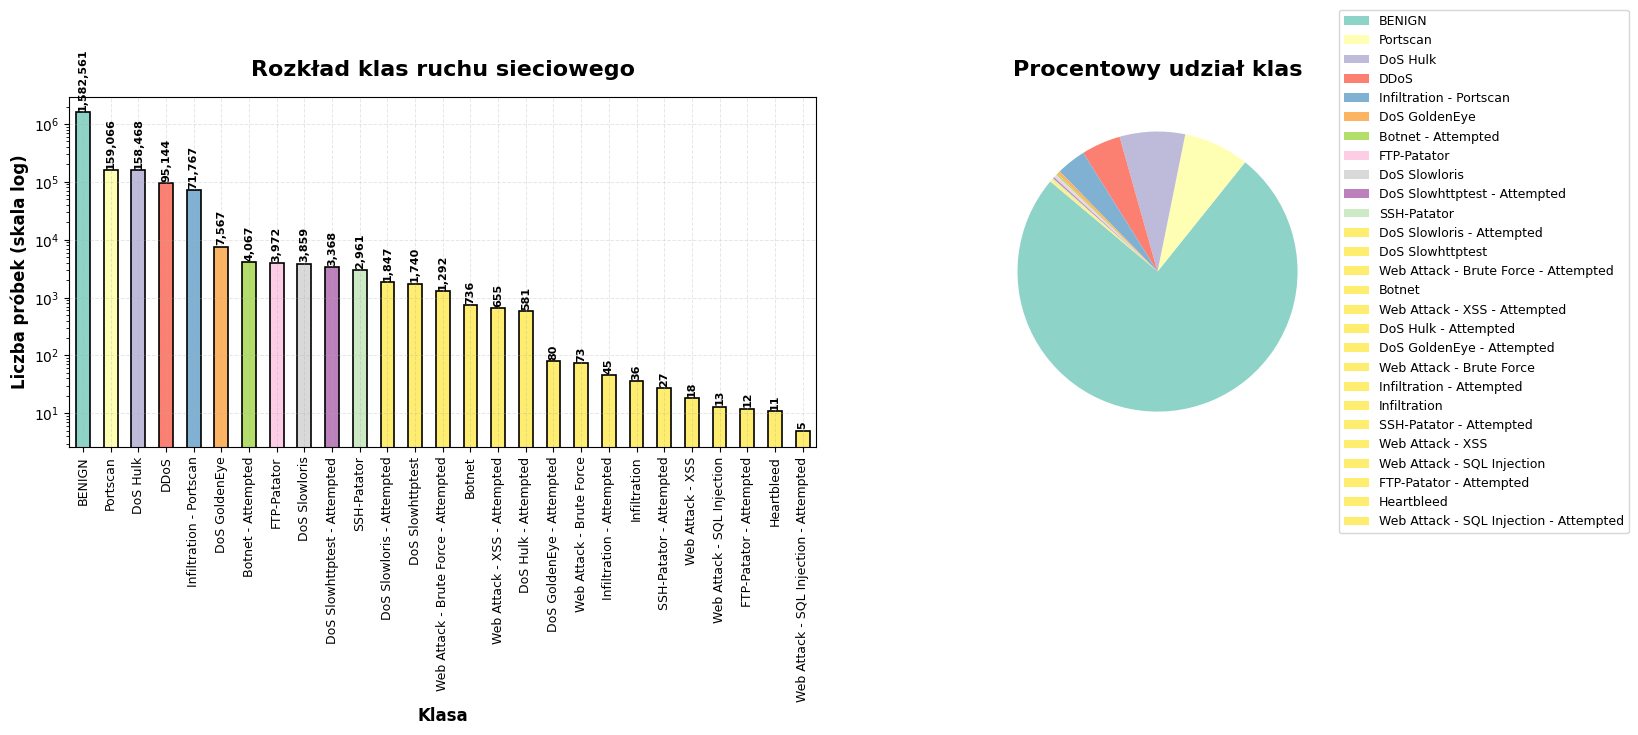

In [32]:
label_counts = df['Label'].value_counts()
print(label_counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors = plt.cm.Set3(range(len(label_counts)))

label_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_yscale('log')
axes[0].set_title('Rozkład klas ruchu sieciowego', fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('Klasa', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Liczba próbek (skala log)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=90, labelsize=9)
axes[0].tick_params(axis='y', labelsize=10)
axes[0].grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v * 1.15, f'{v:,}', ha='center', fontsize=8, fontweight='bold', rotation=90)

wedges, autotexts = axes[1].pie(
    label_counts, 
    #autopct='%1.1f%%', 
    startangle=140,
    colors=colors,
    textprops={'fontsize': 9, 'fontweight': 'bold'},
    pctdistance=0.85
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(8)
axes[1].set_title('Procentowy udział klas', fontsize=16, fontweight='bold', pad=15)
axes[1].legend(
    label_counts.index,
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=9,
    frameon=True
)

plt.tight_layout()
plt.savefig(MODEL_DIR / 'label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
DROP_COLS = [
    'Flow ID', 'Timestamp',
    'Src IP dec', 'Dst IP dec',
    'Local', *[f'Local_{i}' for i in range(1, 15)],
    'Attempted Category',
]

existing_drop = [c for c in DROP_COLS if c in df.columns]
df.drop(columns=existing_drop, inplace=True)
print(f'Usunięte kolumny: {existing_drop}')

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
print(f'Uzupełniono NaN medianą w {len(num_cols)} kolumnach.')

zero_var = [c for c in num_cols if df[c].std() == 0]
df.drop(columns=zero_var, inplace=True)
print(f'Usunięto kolumny zerowej wariancji: {len(zero_var)}')

num_cols     = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = list(num_cols)
print(f'Pozostałe cechy: {len(feature_cols)}')


Usunięte kolumny: ['Flow ID', 'Timestamp', 'Src IP dec', 'Dst IP dec', 'Local', 'Local_1', 'Local_2', 'Local_3', 'Local_4', 'Local_5', 'Local_6', 'Local_7', 'Local_8', 'Local_9', 'Local_10', 'Local_11', 'Local_12', 'Local_13', 'Local_14', 'Attempted Category']
Uzupełniono NaN medianą w 84 kolumnach.
Usunięto kolumny zerowej wariancji: 0
Pozostałe cechy: 84


In [34]:
DROP_COLS = [
    'Flow ID', 'Timestamp',
    'Src IP dec', 'Dst IP dec',
    'Local', *[f'Local_{i}' for i in range(1, 15)],
    'Attempted Category',
]

existing_drop = [c for c in DROP_COLS if c in df.columns]
df.drop(columns=existing_drop, inplace=True)
print(f'Usunięte kolumny: {existing_drop}')

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
print(f'Uzupełniono NaN medianą w {len(num_cols)} kolumnach.')

zero_var = [c for c in num_cols if df[c].std() == 0]
df.drop(columns=zero_var, inplace=True)
print(f'Usunięto kolumny zerowej wariancji: {len(zero_var)}')

num_cols     = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = list(num_cols)
print(f'Pozostałe cechy: {len(feature_cols)}')


Usunięte kolumny: []
Uzupełniono NaN medianą w 84 kolumnach.
Usunięto kolumny zerowej wariancji: 0
Pozostałe cechy: 84


In [35]:
le = LabelEncoder()
y_multi  = le.fit_transform(df['Label'])
y_binary = (df['Label'] != 'BENIGN').astype(int).values

print(f'Klasy ({len(le.classes_)}):')
for i, cls in enumerate(le.classes_):
    count = (y_multi == i).sum()
    pct   = count / len(y_multi) * 100
    print(f'  {i:2d}: {cls:<30s}  {count:>8,}  ({pct:.2f}%)')

joblib.dump(le, MODEL_DIR / 'label_encoder.pkl')
print('\nZapisano → label_encoder.pkl')


Klasy (27):
   0: BENIGN                          1,582,561  (75.36%)
   1: Botnet                               736  (0.04%)
   2: Botnet - Attempted                 4,067  (0.19%)
   3: DDoS                              95,144  (4.53%)
   4: DoS GoldenEye                      7,567  (0.36%)
   5: DoS GoldenEye - Attempted             80  (0.00%)
   6: DoS Hulk                         158,468  (7.55%)
   7: DoS Hulk - Attempted                 581  (0.03%)
   8: DoS Slowhttptest                   1,740  (0.08%)
   9: DoS Slowhttptest - Attempted       3,368  (0.16%)
  10: DoS Slowloris                      3,859  (0.18%)
  11: DoS Slowloris - Attempted          1,847  (0.09%)
  12: FTP-Patator                        3,972  (0.19%)
  13: FTP-Patator - Attempted               12  (0.00%)
  14: Heartbleed                            11  (0.00%)
  15: Infiltration                          36  (0.00%)
  16: Infiltration - Attempted              45  (0.00%)
  17: Infiltration - Portscan     

In [36]:
X = df[feature_cols].values.astype(np.float32)
\
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw).astype(np.float32)  
X_test  = scaler.transform(X_test_raw).astype(np.float32)       

joblib.dump(scaler, MODEL_DIR / 'scaler.pkl')

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'\nPrzykład normalizacji ("{feature_cols[0]}"):')
print(f'  PRZED: mean={X_train_raw[:,0].mean():.1f}, std={X_train_raw[:,0].std():.1f}')
print(f'  PO:    mean={X_train[:,0].mean():.3f}, std={X_train[:,0].std():.3f}')
print('Zapisano → scaler.pkl')


Train: (1679976, 84)  |  Test: (419995, 84)

Przykład normalizacji ("Src Port"):
  PRZED: mean=48490.2, std=15950.5
  PO:    mean=0.000, std=1.000
Zapisano → scaler.pkl


Top 20 cech:
   1. Fwd Seg Size Min                        : 0.5435
   2. Protocol                                : 0.5428
   3. Bwd Packet Length Std                   : 0.5408
   4. Packet Length Variance                  : 0.5363
   5. Packet Length Std                       : 0.5241
   6. Bwd Packet Length Max                   : 0.5151
   7. Bwd Packet Length Mean                  : 0.5144
   8. Bwd Segment Size Avg                    : 0.5144
   9. Packet Length Max                       : 0.5028
  10. RST Flag Count                          : 0.4846
  11. Subflow Bwd Bytes                       : 0.4742
  12. Packet Length Min                       : 0.4555
  13. Bwd RST Flags                           : 0.4482
  14. Packet Length Mean                      : 0.4399
  15. Average Packet Size                     : 0.4399
  16. SYN Flag Count                          : 0.4220
  17. Bwd Packet Length Min                   : 0.4120
  18. Bwd Bulk Rate Avg                       : 0.36

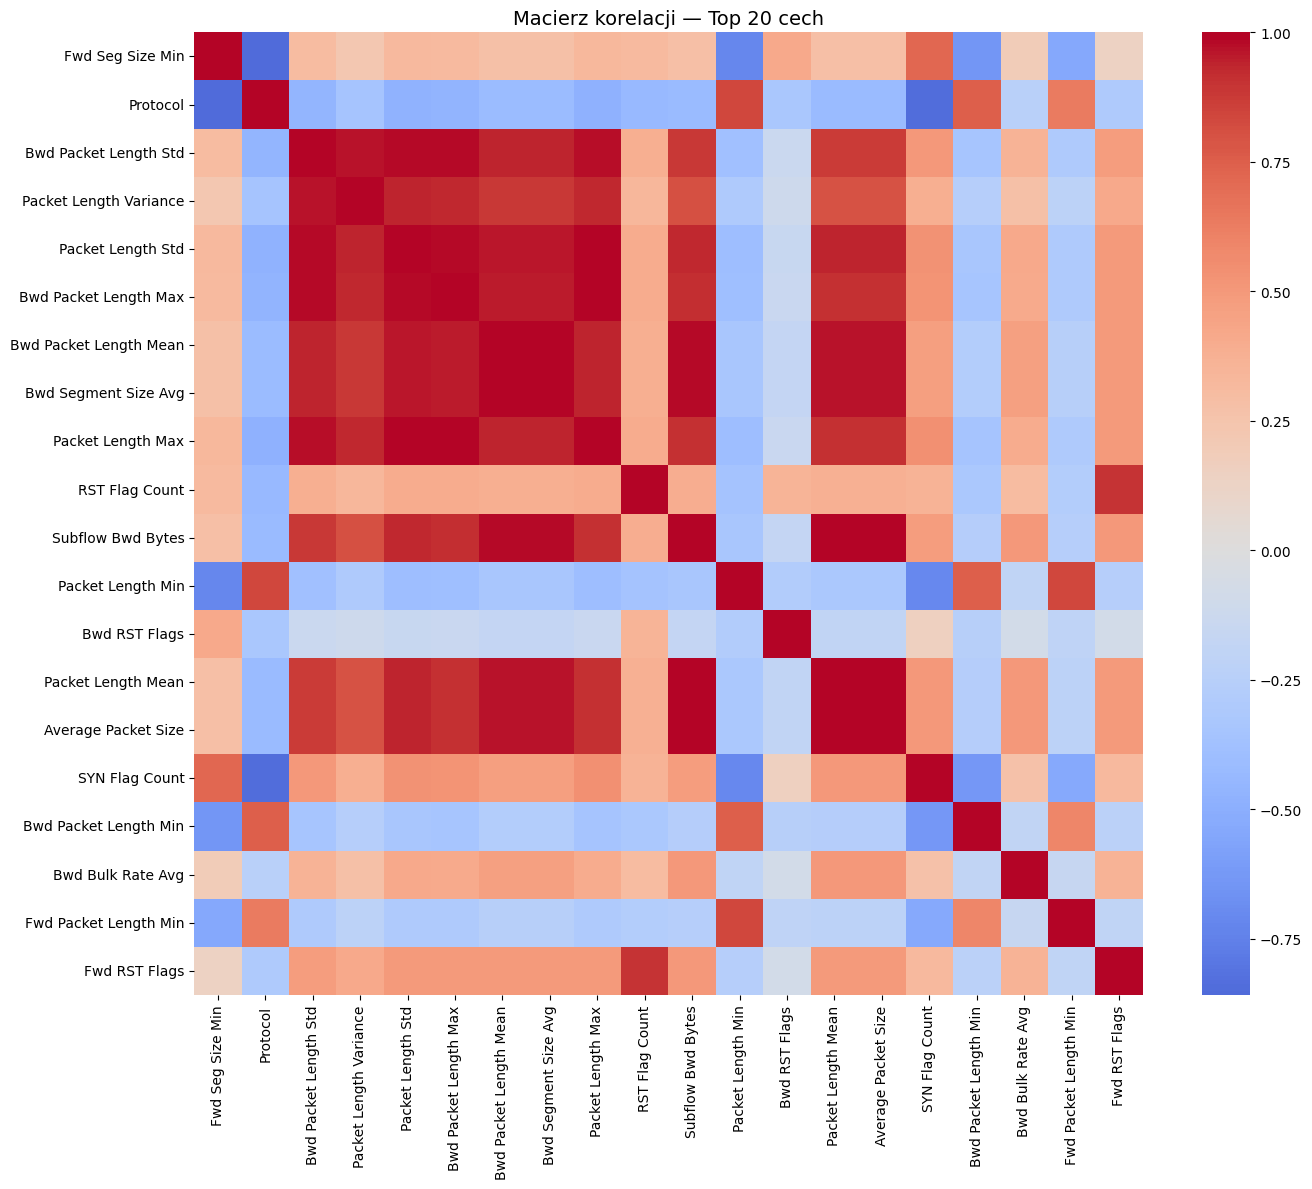

In [37]:
df_corr    = df[feature_cols].copy()
binary_ser = pd.Series(y_binary, index=df.index, name='Attack')

target_corr = df_corr.corrwith(binary_ser).abs().sort_values(ascending=False)
top20       = target_corr.head(20).index.tolist()

print('Top 20 cech:')
for i, (feat, corr) in enumerate(target_corr.head(20).items(), 1):
    print(f'  {i:2d}. {feat:<40s}: {corr:.4f}')

corr_matrix = df_corr[top20].corr()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Macierz korelacji — Top 20 cech', fontsize=14)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'correlation_matrix.png', dpi=150)
plt.show()


In [38]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

BATCH_SIZE = 1024

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Batch size    : {BATCH_SIZE}')
print(f'Train batches : {len(train_loader)}')
print(f'Test  batches : {len(test_loader)}')


Batch size    : 1024
Train batches : 1641
Test  batches : 411


In [39]:
class NetworkAnomalyNet(nn.Module):
    def __init__(self, input_dim: int, num_classes: int, dropout: float = 0.3):
        super().__init__()

        self.network = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.network(x)

    def predict_proba(self, x):
        with torch.no_grad():
            return torch.softmax(self.forward(x), dim=1)


INPUT_DIM   = X_train.shape[1]
NUM_CLASSES = len(le.classes_)

model = NetworkAnomalyNet(INPUT_DIM, NUM_CLASSES).to(device)
print(model)
print(f'\nParametry: {sum(p.numel() for p in model.parameters()):,}')


NetworkAnomalyNet(
  (network): Sequential(
    (0): BatchNorm1d(84, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Linear(in_features=84, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Linear(in_features=128, out_features=64, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=27, bias=True)
  )
)

Parametry: 65,603


In [40]:
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_t = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6, verbose=True
)

print('Wagi klas:')
for cls, w in zip(le.classes_, class_weights_np):
    print(f'  {cls:<30s}: {w:.4f}')


Wagi klas:
  BENIGN                        : 0.0491
  Botnet                        : 105.6389
  Botnet - Attempted            : 19.1215
  DDoS                          : 0.8175
  DoS GoldenEye                 : 10.2794
  DoS GoldenEye - Attempted     : 972.2083
  DoS Hulk                      : 0.4908
  DoS Hulk - Attempted          : 133.8093
  DoS Slowhttptest              : 44.6992
  DoS Slowhttptest - Attempted  : 23.0963
  DoS Slowloris                 : 20.1559
  DoS Slowloris - Attempted     : 42.0983
  FTP-Patator                   : 19.5788
  FTP-Patator - Attempted       : 6222.1333
  Heartbleed                    : 6913.4815
  Infiltration                  : 2145.5632
  Infiltration - Attempted      : 1728.3704
  Infiltration - Portscan       : 1.0837
  Portscan                      : 0.4890
  SSH-Patator                   : 26.2648
  SSH-Patator - Attempted       : 2828.2424
  Web Attack - Brute Force      : 1072.7816
  Web Attack - Brute Force - Attempted: 60.1754
  Web A

In [ ]:
EPOCHS = 30
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []


def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            total_loss += criterion(logits, yb).item() * len(yb)
            correct    += (logits.argmax(1) == yb).sum().item()
            total      += len(yb)
    return total_loss / total, correct / total


for epoch in range(1, EPOCHS + 1):
    model.train()
    e_loss, e_correct, e_total = 0.0, 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        e_loss    += loss.item() * len(yb)
        e_correct += (logits.argmax(1) == yb).sum().item()
        e_total   += len(yb)

    t_loss, t_acc = e_loss / e_total, e_correct / e_total
    v_loss, v_acc = evaluate(test_loader)
    scheduler.step(v_loss)

    train_losses.append(t_loss); val_losses.append(v_loss)
    train_accs.append(t_acc);    val_accs.append(v_acc)

    print(f'Epoch {epoch:3d}/{EPOCHS}  |  '
          f'Train loss={t_loss:.4f} acc={t_acc:.4f}  |  '
          f'Val loss={v_loss:.4f} acc={v_acc:.4f}')


Epoch   1/30  |  Train loss=0.7369 acc=0.8657  |  Val loss=1.0715 acc=0.9676
Epoch   2/30  |  Train loss=0.4533 acc=0.9564  |  Val loss=0.4278 acc=0.9711
Epoch   3/30  |  Train loss=0.3774 acc=0.9634  |  Val loss=0.3372 acc=0.9680


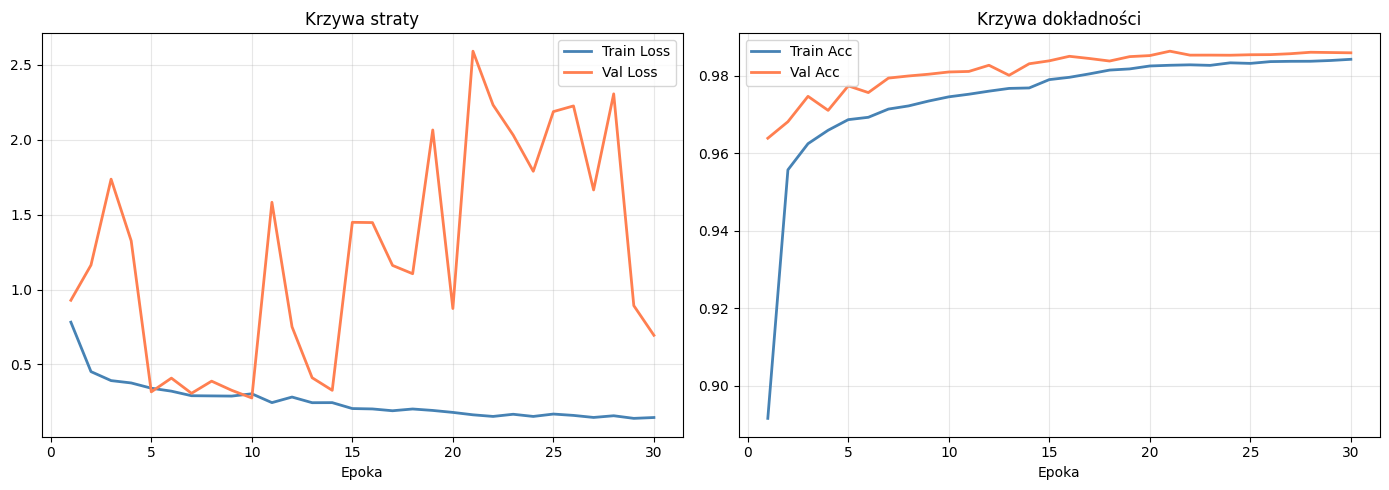

Najlepsza val accuracy: 0.9863 (epoka 21)


In [ ]:
epochs_r = range(1, len(train_losses) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_r, train_losses, label='Train Loss', color='steelblue', lw=2)
axes[0].plot(epochs_r, val_losses,   label='Val Loss',   color='coral',     lw=2)
axes[0].set_title('Krzywa straty'); axes[0].set_xlabel('Epoka')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_r, train_accs, label='Train Acc', color='steelblue', lw=2)
axes[1].plot(epochs_r, val_accs,   label='Val Acc',   color='coral',     lw=2)
axes[1].set_title('Krzywa dokładności'); axes[1].set_xlabel('Epoka')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_DIR / 'learning_curves.png', dpi=150)
plt.show()
print(f'Najlepsza val accuracy: {max(val_accs):.4f} (epoka {val_accs.index(max(val_accs))+1})')


                                        precision    recall  f1-score   support

                                BENIGN       1.00      0.99      0.99    316513
                                Botnet       0.89      1.00      0.94       147
                    Botnet - Attempted       1.00      1.00      1.00       813
                                  DDoS       1.00      1.00      1.00     19029
                         DoS GoldenEye       0.99      1.00      0.99      1514
             DoS GoldenEye - Attempted       0.00      0.00      0.00        16
                              DoS Hulk       1.00      1.00      1.00     31694
                  DoS Hulk - Attempted       0.62      0.99      0.76       116
                      DoS Slowhttptest       0.92      1.00      0.96       348
          DoS Slowhttptest - Attempted       0.87      0.99      0.93       674
                         DoS Slowloris       0.97      1.00      0.99       772
             DoS Slowloris - Attempted 

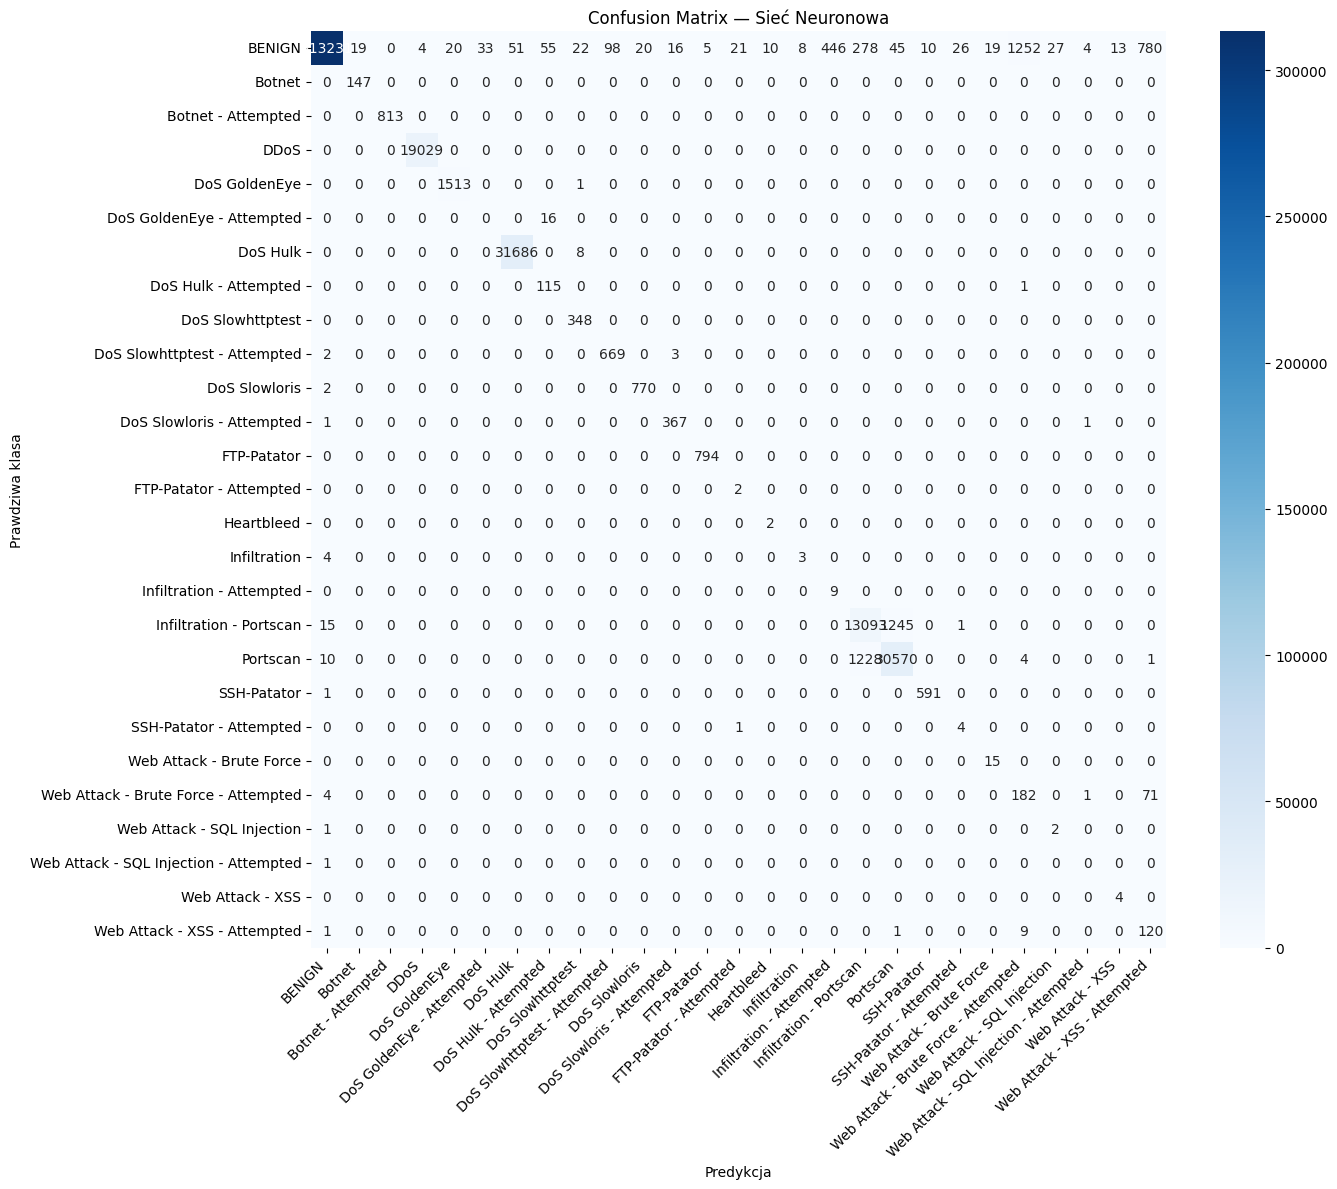

In [ ]:
model.eval()
all_preds, all_labels, all_proba = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb.to(device))
        all_proba.append(torch.softmax(logits, dim=1).cpu().numpy())
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(yb.numpy())

y_pred    = np.array(all_preds)
y_true    = np.array(all_labels)
all_proba = np.vstack(all_proba)

print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predykcja'); ax.set_ylabel('Prawdziwa klasa')
ax.set_title('Confusion Matrix — Sieć Neuronowa')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(MODEL_DIR / 'confusion_matrix.png', dpi=150)
plt.show()


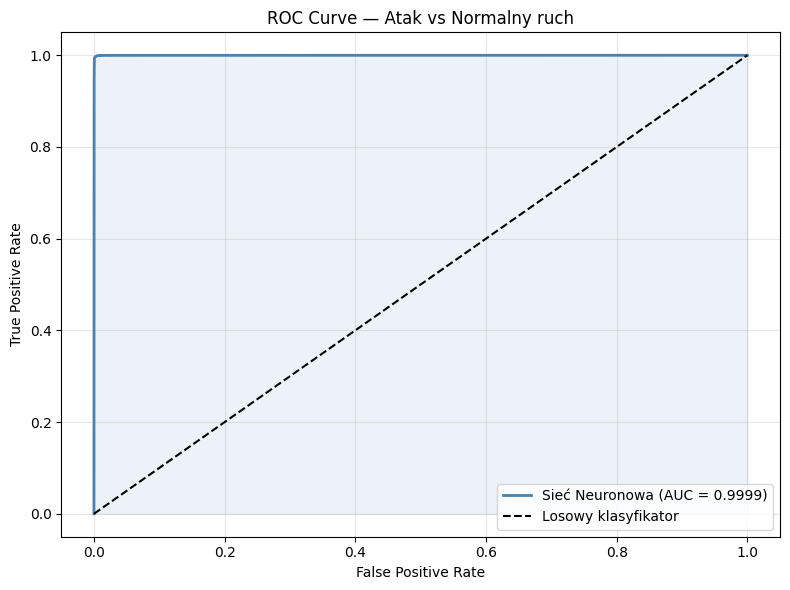

ROC AUC Score: 0.9999


In [ ]:
benign_idx   = list(le.classes_).index('BENIGN')
attack_proba = 1.0 - all_proba[:, benign_idx]
y_test_bin   = (y_true != benign_idx).astype(int)

fpr, tpr, _ = roc_curve(y_test_bin, attack_proba)
auc_score   = roc_auc_score(y_test_bin, attack_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, label=f'Sieć Neuronowa (AUC = {auc_score:.4f})', color='steelblue', lw=2)
ax.plot([0, 1], [0, 1], 'k--', label='Losowy klasyfikator')
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Atak vs Normalny ruch')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'roc_curve.png', dpi=150)
plt.show()
print(f'ROC AUC Score: {auc_score:.4f}')


In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'input_dim': INPUT_DIM,
    'num_classes': NUM_CLASSES,
    'feature_cols': feature_cols
}, MODEL_DIR / 'model_multiclass.pt')

print('Zapisane pliki:')
print(f'model_multiclass.pt - wagi sieci')
print(f'scaler.pkl - Standard Scaler')
print(f'label_encoder.plk - LabelEncoder')

ckpt = torch.load(MODEL_DIR / 'model_multiclass.pt', map_location='cpu')
v_model = NetworkAnomalyNet(ckpt['input_dim'],ckpt['num_classes'])
v_model.load_state_dict(ckpt['model_state_dict'])
v_model.eval()

with torch.no_grad():
    preds_v = v_model(torch.tensor(X_test[:5])).argmax(1).numpy()

print('\n Weryfikacja 5 próbek:')
print(f' Predykcje: {le.inverse_transform(preds_v)}')
print(f' Rzeczywiste: {le.inverse_transform(y_pred[:5])}')

Zapisane pliki:
model_multiclass.pt - wagi sieci
scaler.pkl - Standard Scaler
label_encoder.plk - LabelEncoder

 Weryfikacja 5 próbek:
 Predykcje: ['DDoS' 'Web Attack - XSS - Attempted' 'Portscan' 'BENIGN' 'BENIGN']
 Rzeczywiste: ['DDoS' 'Web Attack - XSS - Attempted' 'Portscan' 'BENIGN' 'BENIGN']
